<a href="https://colab.research.google.com/github/BakaPika/PCS221_Cloud-Infrastructure-and-Services/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part I: Randomized Sales Data Generation (NumPy)
1. Initialize Random Seed
2. Generate Sales Data
• Create a NumPy array of random sales data for 12 months (shape = (12, 4)),
where each column represents a product category:
• Electronics, Clothing, Home & Kitchen, Sports.
• Sales valuesshould be between 1000 and 5000 units per month.
• The range should be randomized using the seed.
3. Convert to DataFrame
• Convert the cleaned NumPy array into a Pandas DataFrame with:
i. Columns: Electronics, Clothing, Home & Kitchen, Sports
ii. Index: Monthsfrom Jan to Dec

In [2]:
import numpy as np
import pandas as pd

ROLL_NUMBER = 8025320083
np.random.seed(ROLL_NUMBER % (2**32)) # % (2**32) ensures the number fits within NumPy’s allowed seed range.

In [3]:
sales_data = np.random.randint(1000, 5001, size=(12, 4)) # between range 1000 and 5001 with 12 rows and 4 columns.

sales_data

array([[2754, 3113, 3037, 4939],
       [3224, 4789, 2121, 4071],
       [3946, 2030, 2194, 1810],
       [1332, 2119, 4836, 1758],
       [4913, 2986, 1475, 4493],
       [2170, 4913, 1794, 2764],
       [3019, 4858, 2994, 2971],
       [2679, 2501, 3780, 2154],
       [1073, 2599, 1718, 2559],
       [3388, 3674, 4286, 4703],
       [2217, 3466, 3106, 1164],
       [4161, 1483, 1862, 3494]])

In [4]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

columns = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']

df = pd.DataFrame(sales_data, columns=columns, index=months) # converts the raw data into structured tabular format.

df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,2754,3113,3037,4939
Feb,3224,4789,2121,4071
Mar,3946,2030,2194,1810
Apr,1332,2119,4836,1758
May,4913,2986,1475,4493
Jun,2170,4913,1794,2764
Jul,3019,4858,2994,2971
Aug,2679,2501,3780,2154
Sep,1073,2599,1718,2559
Oct,3388,3674,4286,4703


Part II: Data Manipulation and Analysis(Pandas)
1. Display the first 5 rows and summary statistics of the DataFrame.
2. Calculate the total sales per category and total sales per month.
3. Calculate the average sales growth between consecutive monthsfor each category.
4. Add the following columns to the DataFrame:
• Total Sales: Sum of all categories per month.
• Growth Rate: Percentage change in Total Salesfrom the previous month.
5. Apply a randomized discount:
• If your roll number is even, apply a 10% discount to the Electronics category.
• If odd, apply a 15% discount to the Clothing category.

In [5]:
df.head() # showcases the first five rows

,Electronics,Clothing,Home & Kitchen,Sports
Jan,2754,3113,3037,4939
Feb,3224,4789,2121,4071
Mar,3946,2030,2194,1810
Apr,1332,2119,4836,1758
May,4913,2986,1475,4493


In [6]:
df.describe() # mean, min/max, std deviation

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,2906.333333,3210.916667,2766.916667,3073.333333
std,1126.511295,1163.496803,1092.732393,1261.738219
min,1073.000000,1483.000000,1475.000000,1164.000000
25%,2205.250000,2405.500000,1845.000000,2068.000000
50%,2886.500000,3049.500000,2594.000000,2867.500000
75%,3527.500000,3952.750000,3274.500000,4176.500000
max,4913.000000,4913.000000,4836.000000,4939.000000


In [7]:
# Total per category
category_totals = df.sum()
print(category_totals) # total sum per category

# Total per month
df['Total Sales'] = df.sum(axis=1)
df

Electronics       34876
Clothing          38531
Home & Kitchen    33203
Sports            36880
dtype: int64


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales
Jan,2754,3113,3037,4939,13843
Feb,3224,4789,2121,4071,14205
Mar,3946,2030,2194,1810,9980
Apr,1332,2119,4836,1758,10045
May,4913,2986,1475,4493,13867
Jun,2170,4913,1794,2764,11641
Jul,3019,4858,2994,2971,13842
Aug,2679,2501,3780,2154,11114
Sep,1073,2599,1718,2559,7949
Oct,3388,3674,4286,4703,16051


In [8]:
growth = df[columns].pct_change() # change in comparison to last row.
avg_growth = growth.mean() # average growth rate.

print(avg_growth)

Electronics       0.384560
Clothing          0.035301
Home & Kitchen    0.151193
Sports            0.226003
dtype: float64


In [9]:
df['Growth Rate'] = df['Total Sales'].pct_change() * 100 # percentage change in sales.

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2754,3113,3037,4939,13843,NaN
Feb,3224,4789,2121,4071,14205,2.615040
Mar,3946,2030,2194,1810,9980,-29.743048
Apr,1332,2119,4836,1758,10045,0.651303
May,4913,2986,1475,4493,13867,38.048780
Jun,2170,4913,1794,2764,11641,-16.052499
Jul,3019,4858,2994,2971,13842,18.907310
Aug,2679,2501,3780,2154,11114,-19.708135
Sep,1073,2599,1718,2559,7949,-28.477596
Oct,3388,3674,4286,4703,16051,101.924770


In [10]:
if ROLL_NUMBER % 2 == 0: # checking discoud based on odd or even roll number
    df['Electronics'] = df['Electronics'] * 0.9 # applied 10% discount on electronics if even
    print("10% discount applied to Electronics")
else:
    df['Clothing'] = df['Clothing'] * 0.85 # 15 percent discount of clothing if off roll number
    print("15% discount applied to Clothing")

df

15% discount applied to Clothing


,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,2754,2646.05,3037,4939,13843,NaN
Feb,3224,4070.65,2121,4071,14205,2.615040
Mar,3946,1725.50,2194,1810,9980,-29.743048
Apr,1332,1801.15,4836,1758,10045,0.651303
May,4913,2538.10,1475,4493,13867,38.048780
Jun,2170,4176.05,1794,2764,11641,-16.052499
Jul,3019,4129.30,2994,2971,13842,18.907310
Aug,2679,2125.85,3780,2154,11114,-19.708135
Sep,1073,2209.15,1718,2559,7949,-28.477596
Oct,3388,3122.90,4286,4703,16051,101.924770


Part III: Visualizations(Matplotlib and Seaborn)
1. Plot monthly salestrendsfor each category using line plots.
2. Create the following plots:
• Box plotsto show the sales distribution for each category.

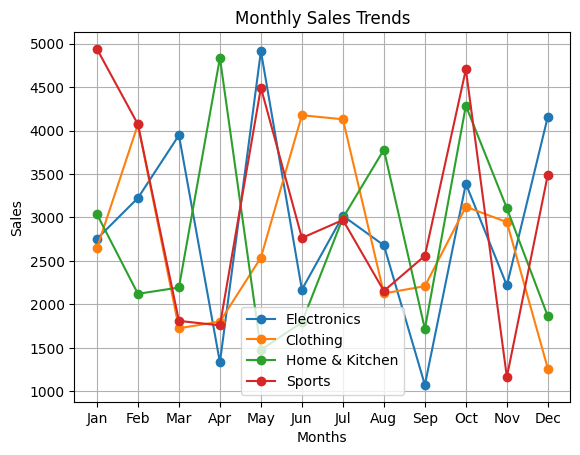

In [26]:
import matplotlib.pyplot as plt # for basic plotting
import seaborn as sns # for advance plotting


for col in columns:
    plt.plot(df.index, df[col], marker='o', label=col)

plt.title("Monthly Sales Trends")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

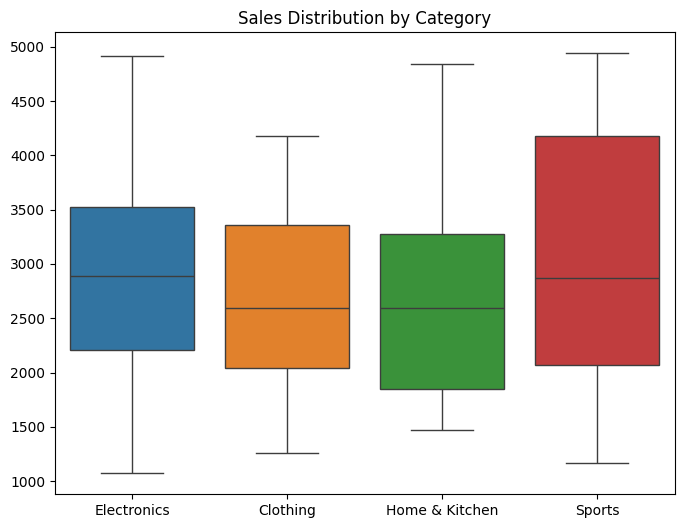

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[columns])

plt.title("Sales Distribution by Category")
plt.show()

Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
i. Find element-wise absolute value
ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each
row.
iii. Mean, Median and Standard Deviation of flattened array, of each column, and
each row

In [13]:
array = np.array([[1, -2, 3], [-4, 5, -6]])

In [14]:
np.abs(array)

array([[1, 2, 3],
       [4, 5, 6]])

In [31]:
flat = array.flatten()

# Flattened
flat = np.percentile(flat, [25, 50, 75])
print(flat)
print()

# Column-wise
col = np.percentile(array, [25, 50, 75], axis=0)
print(col)
print()

# Row-wise
row = np.percentile(array, [25, 50, 75], axis=1)
print(row)

[-3.5 -0.5  2.5]

[[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]

[[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]


In [16]:
# Flattened
print(np.mean(flat), np.median(flat), np.std(flat))

# Column-wise
print(np.mean(array, axis=0))
print(np.median(array, axis=0))
print(np.std(array, axis=0))

# Row-wise
print(np.mean(array, axis=1))
print(np.median(array, axis=1))
print(np.std(array, axis=1))

-0.5 -0.5 3.8622100754188224
[-1.5  1.5 -1.5]
[-1.5  1.5 -1.5]
[2.5 3.5 4.5]
[ 0.66666667 -1.66666667]
[ 1. -4.]
[2.05480467 4.78423336]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).
i. Find floor, ceiling and truncated value,rounded values

Q.4 WAP to swap two elementsin a list in Python Using a Temporary Variable.

Q.5 Write a Python program to swap two elementsin a set by converting it to a list first

In [17]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceil:", np.ceil(a))
print("Truncate:", np.trunc(a))
print("Round:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceil: [-1. -1. -0.  1.  2.  2.  3.]
Truncate: [-1. -1. -0.  0.  1.  1.  3.]
Round: [-2. -2. -0.  0.  2.  2.  3.]


In [18]:
def swap_list(lst, i, j):
    temp = lst[i]
    lst[i] = lst[j]
    lst[j] = temp
    return lst

lst = [1, 2, 3, 4]
print(swap_list(lst, 1, 3))

[1, 4, 3, 2]


In [19]:
def swap_set(s, i, j):
    lst = list(s)

    temp = lst[i]
    lst[i] = lst[j]
    lst[j] = temp

    return set(lst)

s = {1, 2, 3, 4}
print(swap_set(s, 0, 2))

{1, 2, 3, 4}
